# Exploring g3 Frames

This is an example notebook to investigate g3 frames, and to understand the relationship between detector focalplane offsets and on-sky pointing offsets

In [1]:
from spt3g import core

# Open the g3 file
g3_file = '../../ccat_datacenter_mock/mockdata/planet_ATMdata_d3426/sim_PCAM280_g3_Jupiter_d3426/Jupiter-0-0/frames-0000.g3'

# Iterate over frames
for i, frame in enumerate(core.G3File(g3_file)):
    print(f"=== Frame {i} ({frame.type}) ===")
    for key in frame.keys():
        val = frame[key]
        print(f"  {key} : {type(val)}")
    print()

=== Frame 0 (Observation) ===
  scan_max_az_astropy_units : <class 'str'>
  scan_max_az : <class 'float'>
  scan_max_el_astropy_units : <class 'str'>
  scan_el : <class 'float'>
  session_start : <class 'spt3g.core.G3Time'>
  scan_el_astropy_units : <class 'str'>
  site_alt_m : <class 'float'>
  telescope_class : <class 'str'>
  telescope_uid : <class 'int'>
  site_lat_deg : <class 'float'>
  site_uid : <class 'int'>
  session_name : <class 'str'>
  observation_name : <class 'str'>
  site_class : <class 'str'>
  site_lon_deg : <class 'float'>
  telescope_name : <class 'str'>
  scan_min_az_astropy_units : <class 'str'>
  site_weather_name : <class 'str'>
  session_end : <class 'spt3g.core.G3Time'>
  scan_min_el_astropy_units : <class 'str'>
  observation_detector_sets : <class 'spt3g.core.G3VectorVectorString'>
  scan_min_az : <class 'float'>
  observation_uid : <class 'int'>
  scan_max_el : <class 'float'>
  site_weather_realization : <class 'int'>
  site_weather_time : <class 'spt3g.c

In [2]:
# Read everything into a list of frames
frames = list(core.G3File(g3_file))

print(f"Loaded {len(frames)} frames")
print([f"{i}: {fr.type.name}" for i, fr in enumerate(frames)])

# Inspect a specific frame
frame_idx = 1
print(f"{frame_idx}: {frames[frame_idx].type}\n\t{list(frames[frame_idx].keys())}")

Loaded 5 frames
['0: Observation', '1: Calibration', '2: PipelineInfo', '3: Scan', '4: Scan']
1: Calibration
	['focalplane', 'el_noise_model', 'el_noise_model_class', 'noise_model', 'noise_model_class']


### Looking into detector true offsets

In [3]:
import io
import h5py
import numpy as np
from astropy.table import QTable
import astropy.units as u
from toast import qarray as qa


def decode_if_bytes(x):
    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8")
    return x


def quat_to_det_pos(quats):
    """
    Convert detector quaternions to focal-plane x, y positions.

    Returns
    -------
    det_pos : ndarray, shape (Ndet, 3)
        Columns are x [deg], y [deg], z = cos(theta).
    """
    zaxis = np.array([0.0, 0.0, 1.0], dtype=np.float64)

    det_pos = np.zeros((len(quats), 3), dtype=np.float64)

    for i, quat in enumerate(quats):
        rdir = qa.rotate(quat, zaxis).flatten()

        theta = np.arccos(np.clip(rdir[2], -1.0, 1.0))
        mag = np.rad2deg(theta)
        ang = np.arctan2(rdir[1], rdir[0])

        xpos = mag * np.cos(ang)
        ypos = mag * np.sin(ang)

        det_pos[i] = [xpos, ypos, rdir[2]]

    return det_pos

def get_det_xy(fp_table, det_name):
    """
    Return (x_offset, y_offset) in degrees for a detector.

    Parameters
    ----------
    fp_table : astropy.table.QTable
    det_name : str

    Returns
    -------
    x, y : float
        Detector X and Y offsets in degrees.
    """
    mask = fp_table["name"] == det_name

    if not np.any(mask):
        raise KeyError(f"Detector '{det_name}' not found.")

    pos = fp_table["det_pos"][mask][0]
    return pos[0], pos[1]

# Read everything into a list of frames
frames = list(core.G3File(g3_file))
raw = bytes(frames[1]["focalplane"])  # use your frame index

with h5py.File(io.BytesIO(raw), "r") as f:
    data = f["focalplane"][:]

quats = np.asarray(data["quat"], dtype=np.float64)
det_pos = quat_to_det_pos(quats)

fp_table = QTable()

fp_table["name"] = [decode_if_bytes(x) for x in data["name"]]
fp_table["quat"] = quats
fp_table["wafer_slot"] = [decode_if_bytes(x) for x in data["wafer_slot"]]
fp_table["index"] = data["index"]
fp_table["uid"] = data["uid"]

fp_table["det_pos"] = det_pos

fp_table[:10]

name,quat,wafer_slot,index,uid,det_pos
str18,float64[4],str2,int64,int64,float64[3]
w2_p0000_PC_f280_A,-0.0023661384776333906 .. 0.8660078708992881,w2,3426,3274576627,-0.33052402114017804 .. 0.9999446845892623
w2_p0000_PC_f280_B,-0.004994188749293239 .. 0.9659153448046767,w2,3427,656262584,-0.33052402114017804 .. 0.9999446845892623
w2_p0001_PC_f280_A,-0.003865606101606464 .. 0.9914302740988086,w2,3428,98974905,-0.3305244947770152 .. 0.9999467458716598
w2_p0001_PC_f280_B,-0.0051504351412070375 .. 0.7933492489969605,w2,3429,2416928840,-0.3305244947770152 .. 0.9999467458716598
w2_p0002_PC_f280_A,-0.003911065245037263 .. 0.9914297209397916,w2,3430,4139521447,-0.3423132093991333 .. 0.9999445141731778
w2_p0002_PC_f280_B,-0.005260183221811536 .. 0.7933488063595825,w2,3431,755427652,-0.34231320939913346 .. 0.9999445141731778
w2_p0003_PC_f280_A,-0.0021603863148513384 .. 0.8660092344466638,w2,3432,3332517122,-0.33052494832221735 .. 0.9999487507094712
w2_p0003_PC_f280_B,-0.004764703997191913 .. 0.9659160766048813,w2,3433,3787807873,-0.33052494832221735 .. 0.9999487507094712
w2_p0004_PC_f280_A,-0.00216038629960807 .. 0.8660087573737698,w2,3434,3801115080,-0.34231366500085386 .. 0.9999465472328356


In [4]:
print(fp_table['name'])

       name       
------------------
w2_p0000_PC_f280_A
w2_p0000_PC_f280_B
w2_p0001_PC_f280_A
w2_p0001_PC_f280_B
w2_p0002_PC_f280_A
w2_p0002_PC_f280_B
w2_p0003_PC_f280_A
w2_p0003_PC_f280_B
w2_p0004_PC_f280_A
w2_p0004_PC_f280_B
               ...
w2_p1723_PC_f280_A
w2_p1723_PC_f280_B
w2_p1724_PC_f280_A
w2_p1724_PC_f280_B
w2_p1725_PC_f280_A
w2_p1725_PC_f280_B
w2_p1726_PC_f280_A
w2_p1726_PC_f280_B
w2_p1727_PC_f280_A
w2_p1727_PC_f280_B
Length = 3426 rows


In [5]:
### Find offsets for a given det
det_name = "w2_p0000_PC_f280_A"

x_off, y_off = get_det_xy(fp_table, det_name)

### These are the ground truth offsets
print(f"{det_name}: {x_off:.2f}, {x_off:.2f} Degrees")

w2_p0000_PC_f280_A: -0.33, -0.33 Degrees


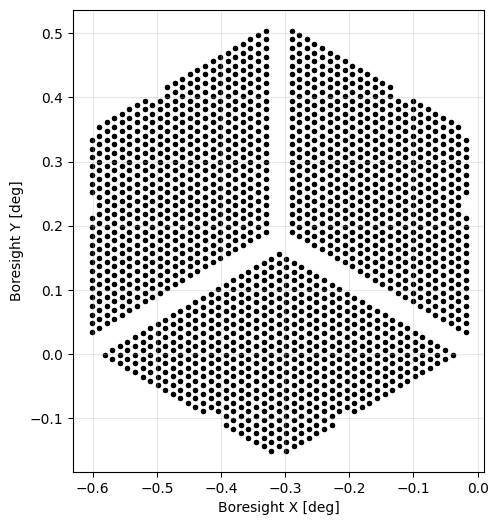

In [6]:
import matplotlib.pyplot as plt

# det_pos columns are: x [deg], y [deg], z = cos(theta)
x_off = fp_table["det_pos"][:, 0]
y_off = fp_table["det_pos"][:, 1]

plt.figure(figsize=(6, 6))
plt.scatter(x_off, y_off, s=8, c="k")

plt.xlabel("Boresight X [deg]")
plt.ylabel("Boresight Y [deg]")
plt.gca().set_aspect("equal")
plt.grid(alpha=0.3)

plt.show()

### Looking into scan frames

In [7]:
from pathlib import Path
from spt3g import core

g3_dir = Path(
    "../../ccat_datacenter_mock/mockdata/planet_ATMdata_d3426/"
    "sim_PCAM280_g3_Jupiter_d3426/Jupiter-0-0"
)

# Find all .g3 files and sort them
g3_files = sorted(g3_dir.glob("frames-*.g3"))

print(f"Found {len(g3_files)} G3 files")

# Load all frames from all files
frames = []
for g3_file in g3_files:
    print(f"Loading {g3_file.name}")
    frames.extend(core.G3File(str(g3_file)))

print(f"\nLoaded {len(frames)} frames")
print([f"{i}: {fr.type.name}" for i, fr in enumerate(frames)])

Found 14 G3 files
Loading frames-0000.g3
Loading frames-0001.g3
Loading frames-0002.g3
Loading frames-0003.g3
Loading frames-0004.g3
Loading frames-0005.g3
Loading frames-0006.g3
Loading frames-0007.g3
Loading frames-0008.g3
Loading frames-0009.g3
Loading frames-0010.g3
Loading frames-0011.g3
Loading frames-0012.g3
Loading frames-0013.g3

Loaded 69 frames
['0: Observation', '1: Calibration', '2: PipelineInfo', '3: Scan', '4: Scan', '5: Observation', '6: Calibration', '7: PipelineInfo', '8: Scan', '9: Scan', '10: Observation', '11: Calibration', '12: PipelineInfo', '13: Scan', '14: Scan', '15: Observation', '16: Calibration', '17: PipelineInfo', '18: Scan', '19: Scan', '20: Observation', '21: Calibration', '22: PipelineInfo', '23: Scan', '24: Scan', '25: Observation', '26: Calibration', '27: PipelineInfo', '28: Scan', '29: Scan', '30: Observation', '31: Calibration', '32: PipelineInfo', '33: Scan', '34: Scan', '35: Observation', '36: Calibration', '37: PipelineInfo', '38: Scan', '39: Sc

Processing G3 frame index 3
Processing G3 frame index 4
Processing G3 frame index 8
Processing G3 frame index 9
Processing G3 frame index 13
Processing G3 frame index 14
Processing G3 frame index 18
Processing G3 frame index 19
Processing G3 frame index 23
Processing G3 frame index 24
Processing G3 frame index 28
Processing G3 frame index 29
Processing G3 frame index 33
Processing G3 frame index 34
Processing G3 frame index 38
Processing G3 frame index 39
Processing G3 frame index 43
Processing G3 frame index 44
Processing G3 frame index 48
Processing G3 frame index 49
Processing G3 frame index 53
Processing G3 frame index 54
Processing G3 frame index 58
Processing G3 frame index 59
Processing G3 frame index 63
Processing G3 frame index 64
Processing G3 frame index 68


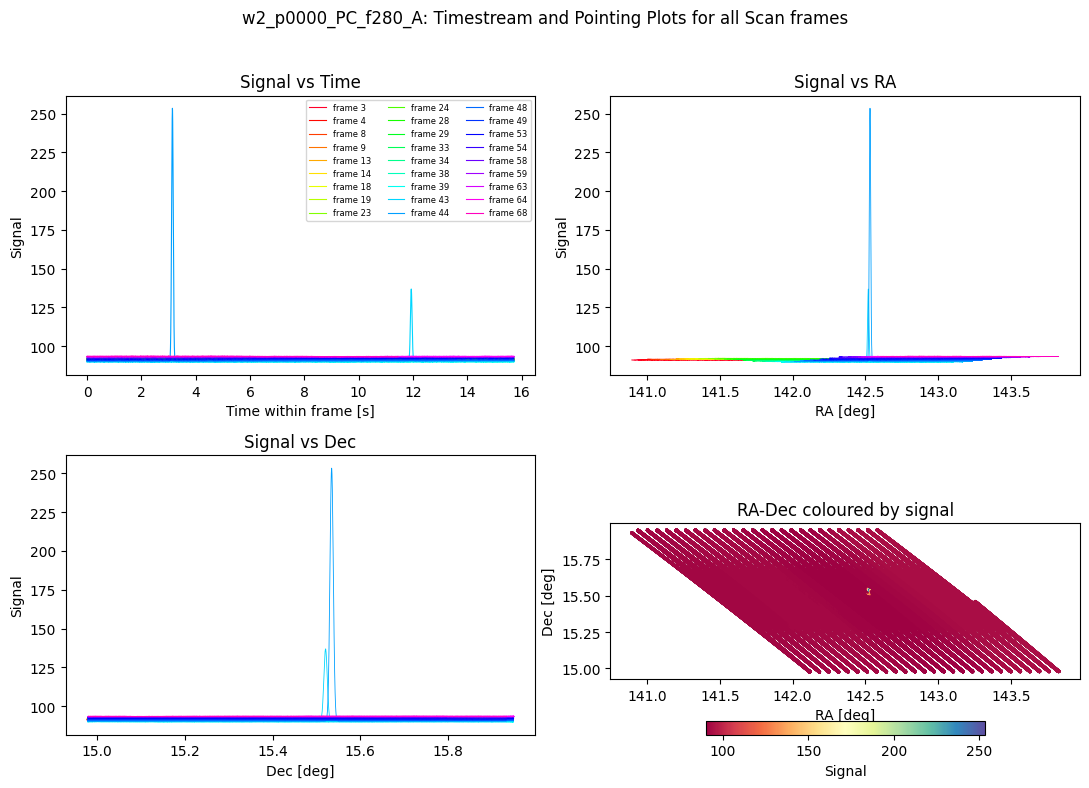

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from spt3g import core

### If checking single g3 file:
# g3_file = '../../ccat_datacenter_mock/mockdata/planet_ATMdata_d3426/sim_PCAM280_g3_Jupiter_d3426/Jupiter-0-0/frames-0008.g3'
# frames = list(core.G3File(g3_file))

plot_single_frame = False # Toggle this for single frame
frame_id = 43             # Choose single frame
fs = 488.0                # Hz
det_name = "w2_p0000_PC_f280_A"

plot_fname = (
    "timestream_all_scan_frames.png"
    if not plot_single_frame else f"timestream_g3frame{frame_id}.png"
)


signals = []
ras = []
decs = []
g3_frame_ids = []

for fr_idx, fr in enumerate(frames):

    if fr.type != core.G3FrameType.Scan:
        continue

    if plot_single_frame and fr_idx != frame_id:
        continue

    print(f"Processing G3 frame index {fr_idx}")

    raw_signal = fr["signal"]

    if det_name not in raw_signal:
        print(f"Skipping G3 frame {fr_idx}: detector {det_name} not found")
        continue

    y_raw = np.asarray(raw_signal[det_name], dtype=float)

    # Signal calibration keys
    gain_key = f"compress_signal_{det_name}_gain"
    offset_key = f"compress_signal_{det_name}_offset"

    if gain_key in fr and offset_key in fr:
        gain = float(fr[gain_key])
        offset = float(fr[offset_key])
        y = y_raw / gain + offset
    else:
        y = y_raw

    radec = np.asarray(fr["shared_radec_deg"], dtype=float).reshape(-1, 2)

    n = min(len(y), radec.shape[0])
    if n == 0:
        print(f"Skipping G3 frame {fr_idx}: no valid samples")
        continue

    signals.append(y[:n])
    ras.append(radec[:n, 0])
    decs.append(radec[:n, 1])
    g3_frame_ids.append(fr_idx)

if not signals:
    raise RuntimeError("No valid Scan frames found.")

title_suffix = (
    f"for G3 frame {frame_id}"
    if plot_single_frame else
    "for all Scan frames"
)

fig, axs = plt.subplots(2, 2, figsize=(11, 8))
(ax1, ax2), (ax3, ax4) = axs

# Uniformly sample the full gist_rainbow colormap
cmap = plt.get_cmap("gist_rainbow")
colors = cmap(np.linspace(0, 1, len(signals)))

for color, signal, ra, dec, g3_idx in zip(
    colors, signals, ras, decs, g3_frame_ids
):
    t = np.arange(len(signal)) / fs
    label = f"frame {g3_idx}"

    ax1.plot(t, signal, lw=0.8, color=color, label=label)
    ax2.plot(ra, signal, lw=0.6, color=color)
    ax3.plot(dec, signal, lw=0.6, color=color)

signal_all = np.concatenate(signals)
ra_all = np.concatenate(ras)
dec_all = np.concatenate(decs)

sc = ax4.scatter(
    ra_all,
    dec_all,
    c=signal_all,
    s=2,
    cmap="Spectral"
)

ax1.set_xlabel("Time within frame [s]")
ax1.set_ylabel("Signal")
ax1.set_title("Signal vs Time")

ax2.set_xlabel("RA [deg]")
ax2.set_ylabel("Signal")
ax2.set_title("Signal vs RA")

ax3.set_xlabel("Dec [deg]")
ax3.set_ylabel("Signal")
ax3.set_title("Signal vs Dec")

ax4.set_xlabel("RA [deg]")
ax4.set_ylabel("Dec [deg]")
ax4.set_title("RA-Dec coloured by signal")
ax4.set_aspect("equal", "box")

cbar = fig.colorbar(sc, ax=ax4, orientation="horizontal", fraction=0.05)
cbar.set_label("Signal")

ax1.legend(fontsize=6, ncol=3)

fig.suptitle(f"{det_name}: Timestream and Pointing Plots {title_suffix}")
fig.tight_layout(rect=[0, 0, 1, 0.96])

# plt.savefig(plot_fname, dpi=150)
plt.show()

w2_p0000_PC_f280_A: -0.33, 0.50 Degrees


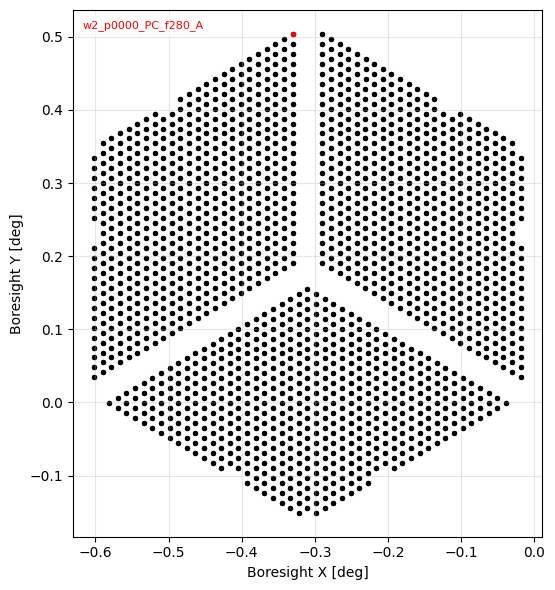

In [9]:
### Find (ground truth) offsets for a given det
import matplotlib.pyplot as plt

# Detector to highlight
det_name = "w2_p0000_PC_f280_A" #"w2_p0104_PC_f280_A"

# Ground-truth position
x_det, y_det = get_det_xy(fp_table, det_name)

### These are the ground truth offsets
print(f"{det_name}: {x_det:.2f}, {y_det:.2f} Degrees")

# All detector positions
x_all = fp_table["det_pos"][:, 0]
y_all = fp_table["det_pos"][:, 1]

plt.figure(figsize=(6, 6))

# All detectors
plt.scatter(x_all, y_all, s=8, c="k")

# Highlight selected detector
plt.scatter(x_det, y_det, s=8, c="red", zorder=5)

# Label it
plt.text(
    0.02, 0.98,
    det_name,
    transform=plt.gca().transAxes,
    color="red",
    fontsize=8,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)

plt.xlabel("Boresight X [deg]")
plt.ylabel("Boresight Y [deg]")
plt.gca().set_aspect("equal")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()